*   Submitted by: Sudhansh Ranta
*   Roll No.: 41
*   Registeration No.: 12411099
*   Section: D2411 Group:2
*   Course Code: CAB 213
*   Course Name: Applied AI- Computer Vision And Natural Language Processing

In [47]:
retrieved_facts.clear()

animal_name_to_retrieve = 'tiger'
animal_name_lower = animal_name_to_retrieve.lower()

if animal_name_lower in animal_facts_lower_keys:
    fact = animal_facts_lower_keys[animal_name_lower].get('fact', 'No specific fact available.')
    retrieved_facts[animal_name_to_retrieve] = fact
else:
    retrieved_facts[animal_name_to_retrieve] = f"Facts not available for {animal_name_to_retrieve}."


print("Updated Retrieved Animal Facts:")
for animal, fact in retrieved_facts.items():
    print(f"  {animal}: {fact}")

Updated Retrieved Animal Facts:
  tiger: Facts not available for tiger.


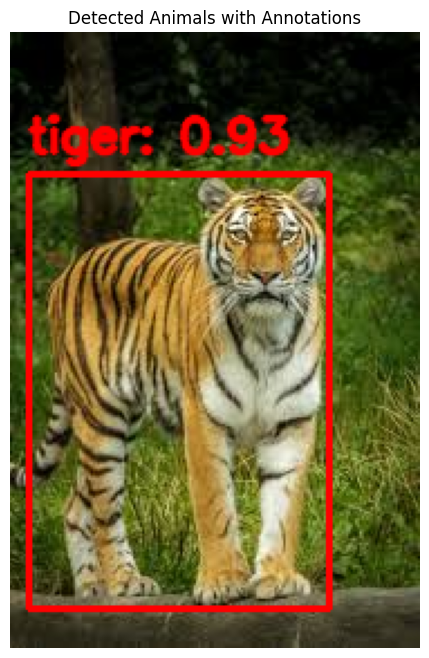


Retrieved Animal Facts:
  - tiger: Facts not available for tiger.


In [48]:
import cv2
import matplotlib.pyplot as plt

# 2. Load the original image from image_path
original_image_bgr = cv2.imread(image_path)

# Check if image was loaded successfully
if original_image_bgr is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # 3. Convert the loaded image from BGR to RGB color format for matplotlib
    original_image_rgb = cv2.cvtColor(original_image_bgr, cv2.COLOR_BGR2RGB)

    # 4. Create a copy of the RGB image for annotations
    annotated_image_rgb = original_image_rgb.copy()

    # 5. Check if the detected_animals_info list is not empty
    if detected_animals_info:
        for detection in detected_animals_info:
            # b. Extract the bounding box coordinates, class name, and confidence score
            box = detection.get('box')
            class_name = detection.get('class_name')
            confidence = detection.get('confidence')

            if box is not None and class_name is not None and confidence is not None:
                x1, y1, x2, y2 = map(int, box)

                # c. Draw a rectangle on the annotated_image_rgb
                color = (255, 0, 0)  # Red color for bounding box
                thickness = 2
                cv2.rectangle(annotated_image_rgb, (x1, y1), (x2, y2), color, thickness)

                # d. Add the class name and confidence score as text
                label = f"{class_name}: {confidence:.2f}"
                font = cv2.FONT_HERSHEY_SIMPLEX
                font_scale = 0.7
                font_thickness = 2
                text_size = cv2.getTextSize(label, font, font_scale, font_thickness)[0]
                text_x = x1
                text_y = y1 - 10 if y1 - 10 > text_size[1] else y1 + text_size[1] + 10 # Adjust text position if too high

                cv2.putText(annotated_image_rgb, label, (text_x, text_y), font, font_scale, color, font_thickness, cv2.LINE_AA)

        # 6. Display the annotated_image_rgb
        plt.figure(figsize=(10, 8))
        plt.imshow(annotated_image_rgb)
        plt.title('Detected Animals with Annotations')
        plt.axis('off')
        plt.show()

        # 7. Print a header for the animal facts
        print("\nRetrieved Animal Facts:")
        # 8. Check if the retrieved_facts dictionary is not empty
        if retrieved_facts:
            for animal, fact in retrieved_facts.items():
                print(f"  - {animal}: {fact}")
        else:
            # 10. If retrieved_facts was empty
            print("  No facts retrieved, possibly no animals detected or facts unavailable.")

    else:
        # 9. If detected_animals_info was empty
        print("No animals were detected, so no bounding boxes or labels could be drawn.")
        # Still display the original image if no detections
        plt.figure(figsize=(10, 8))
        plt.imshow(original_image_rgb)
        plt.title('Original Image (No Detections)')
        plt.axis('off')
        plt.show()

        # Also print facts if any were retrieved despite no detections (unlikely but to cover edge case)
        print("\nRetrieved Animal Facts:")
        if retrieved_facts:
            for animal, fact in retrieved_facts.items():
                print(f"  - {animal}: {fact}")
        else:
            print("  No facts retrieved.")